ГРАФИК 1: Распределение признаков Titanic


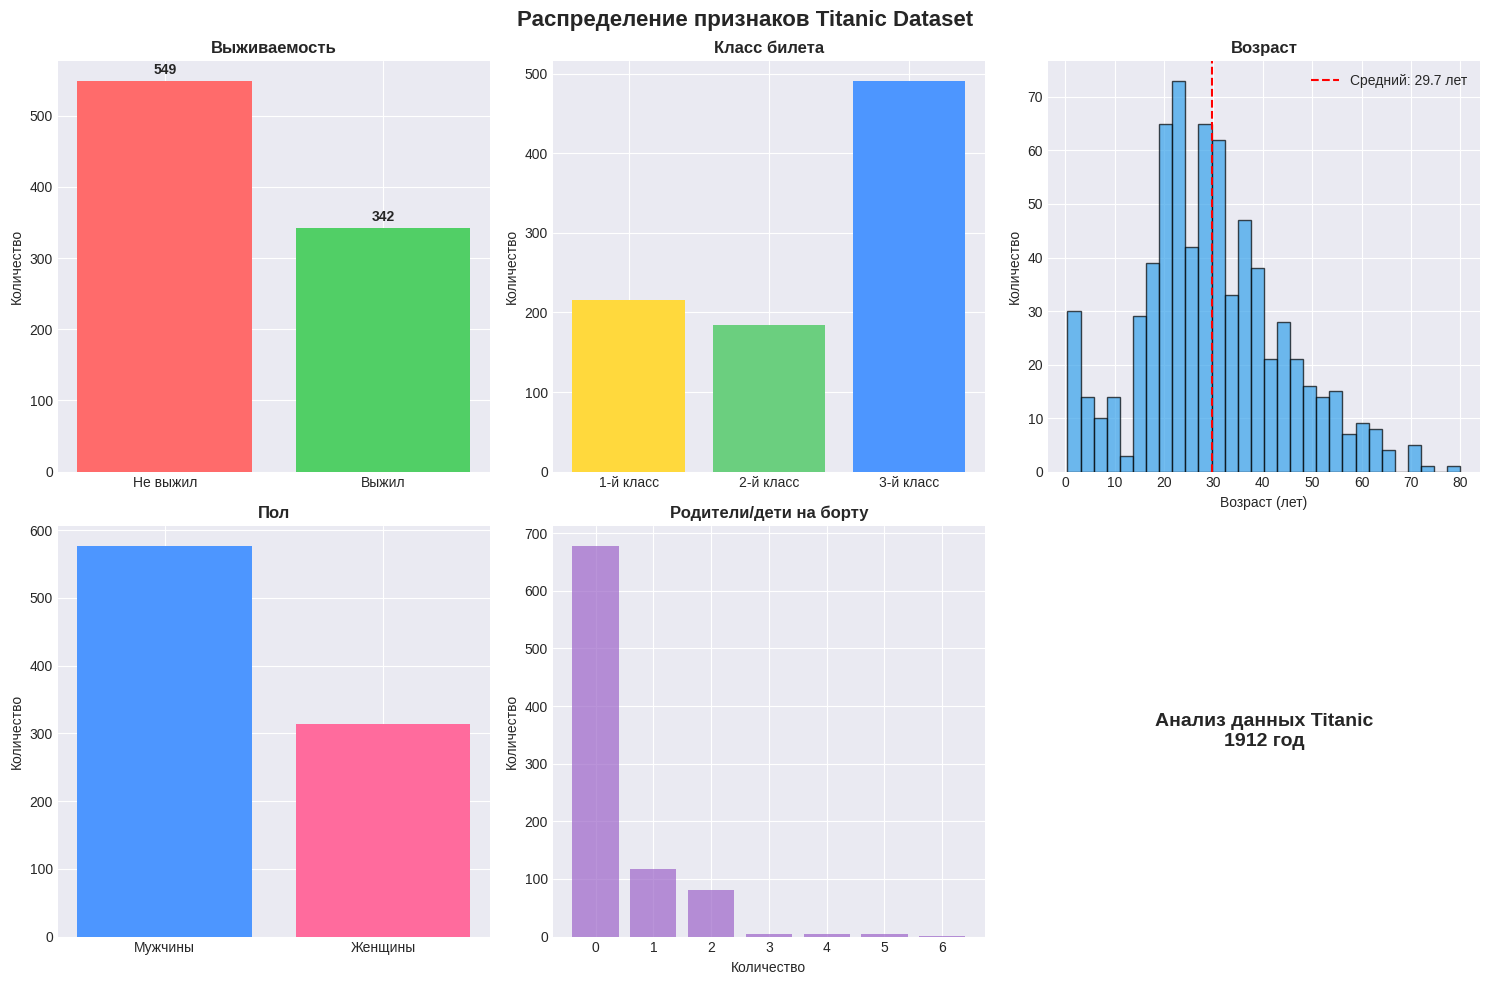


ГРАФИК 2: Boxplot распределения возраста


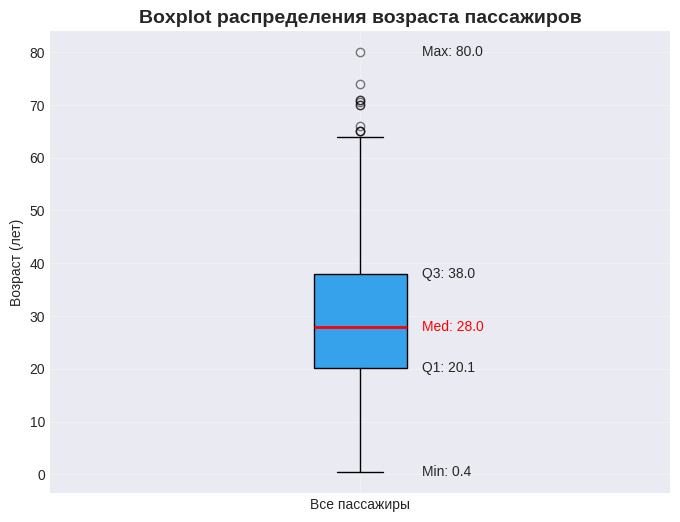


📊 Интерпретация Boxplot возраста:
   • Медиана = 28 лет (50% пассажиров младше 28 лет)
   • Межквартильный размах (IQR): 20-38 лет
   • Выбросы: пассажиры старше ~65 лет
   • Распределение скошено вправо (молодых больше)

ГРАФИК 3: Круговые диаграммы


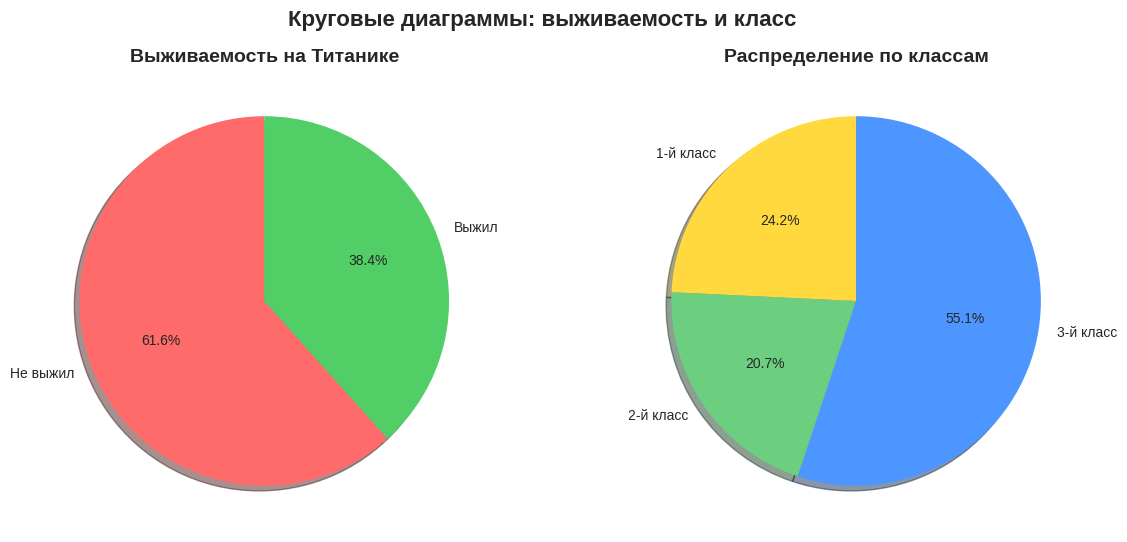


ГРАФИК 4: Pairplot числовых переменных (может занять 5-10 секунд)
Анализируемые признаки: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


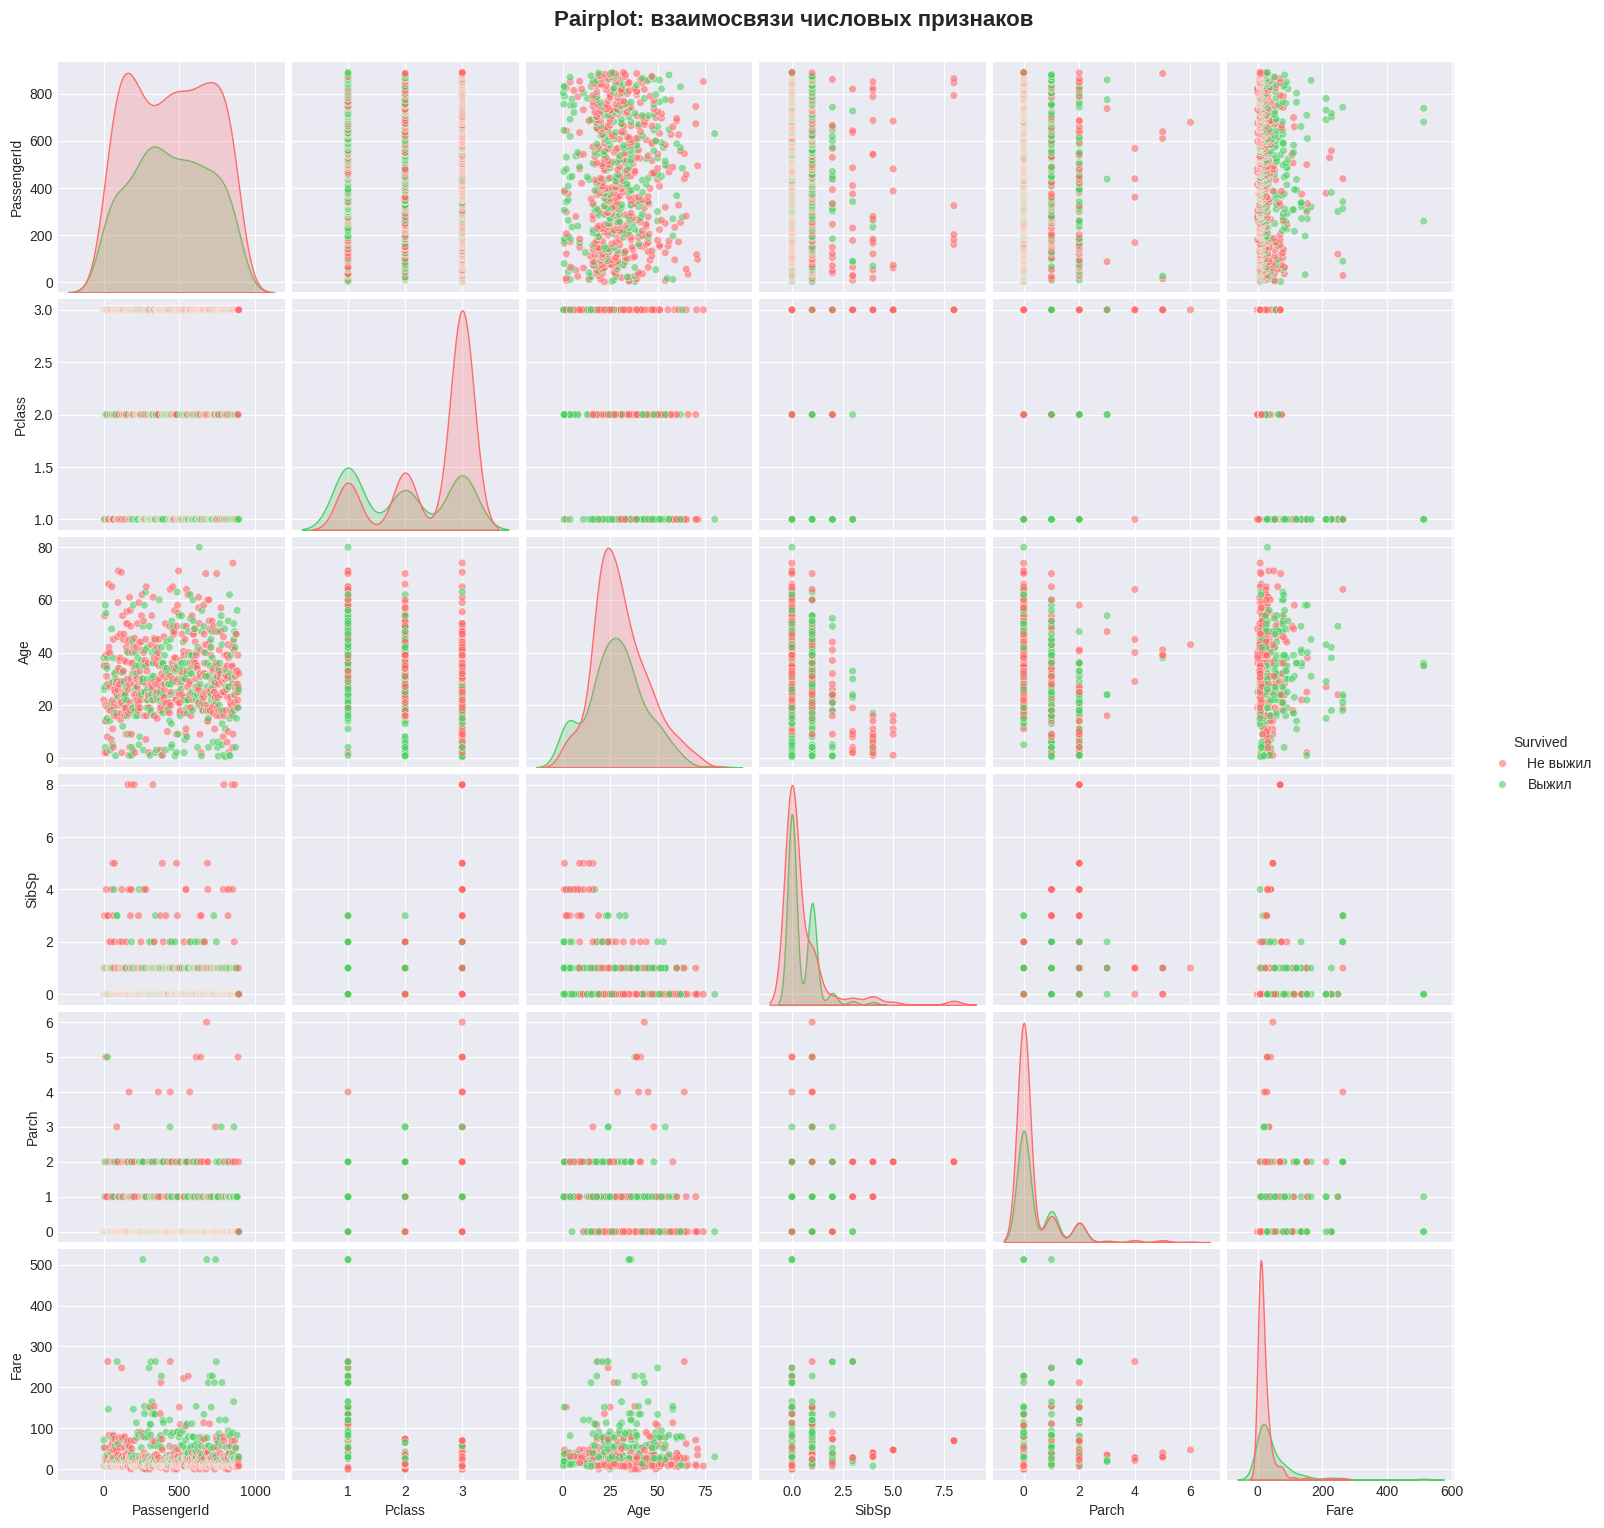


ГРАФИК 5: Sunburst диаграмма (интерактивная)



ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ВИЗУАЛИЗАЦИИ
📌 Общая статистика:
   • Всего пассажиров: 891
   • Выжило: 342 (38.4%)
   • Погибло: 549 (61.6%)

📌 Выживаемость по классам:
   • 1-й класс: 63.0% выживаемости (136 из 216)
   • 2-й класс: 47.3% выживаемости (87 из 184)
   • 3-й класс: 24.2% выживаемости (119 из 491)

📌 Выживаемость по полу:
   • Женщины: 74.2% выживаемости (233 из 314)
   • Мужчины: 18.9% выживаемости (109 из 577)

📌 Возрастной портрет:
   • Средний возраст: 29.7 лет
   • Медианный возраст: 28.0 лет
   • Самый младший: 0.4 лет
   • Самый старший: 80.0 лет


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
df = pd.read_csv('train.csv')

# ========== ГРАФИК 1: Распределение признаков ==========
print("="*60)
print("ГРАФИК 1: Распределение признаков Titanic")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение признаков Titanic Dataset', fontsize=16, fontweight='bold')

# Survived
survived_counts = df['Survived'].value_counts()
axes[0, 0].bar(['Не выжил', 'Выжил'], survived_counts.values, color=['#ff6b6b', '#51cf66'])
axes[0, 0].set_title('Выживаемость', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Количество')
for i, count in enumerate(survived_counts.values):
    axes[0, 0].text(i, count + 10, str(count), ha='center', fontweight='bold')

# Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[0, 1].bar(['1-й класс', '2-й класс', '3-й класс'], pclass_counts.values,
               color=['#ffd93d', '#6bcf7f', '#4d96ff'])
axes[0, 1].set_title('Класс билета', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Количество')

# Age
axes[0, 2].hist(df['Age'].dropna(), bins=30, color='#36a2eb', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Возраст', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Возраст (лет)')
axes[0, 2].set_ylabel('Количество')
axes[0, 2].axvline(df['Age'].mean(), color='red', linestyle='--',
                   label=f'Средний: {df["Age"].mean():.1f} лет')
axes[0, 2].legend()

# Sex
sex_counts = df['Sex'].value_counts()
axes[1, 0].bar(['Мужчины', 'Женщины'], sex_counts.values, color=['#4d96ff', '#ff6b9d'])
axes[1, 0].set_title('Пол', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Количество')

# Parch
parch_counts = df['Parch'].value_counts().sort_index()
axes[1, 1].bar([str(i) for i in parch_counts.index], parch_counts.values,
               color='#9d65c9', alpha=0.7)
axes[1, 1].set_title('Родители/дети на борту', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Количество')
axes[1, 1].set_ylabel('Количество')

axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.5, 'Анализ данных Titanic\n1912 год',
                ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()  # <-- ВАЖНО: show() отображает график в ноутбуке

# ========== ГРАФИК 2: Boxplot возраста ==========
print("\n" + "="*60)
print("ГРАФИК 2: Boxplot распределения возраста")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 6))
box_data = [df['Age'].dropna()]
box = ax.boxplot(box_data, patch_artist=True,
                 boxprops=dict(facecolor='#36a2eb', color='black'),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='black'),
                 capprops=dict(color='black'),
                 flierprops=dict(marker='o', color='red', alpha=0.5))

ax.set_title('Boxplot распределения возраста пассажиров', fontsize=14, fontweight='bold')
ax.set_ylabel('Возраст (лет)')
ax.set_xticklabels(['Все пассажиры'])
ax.grid(True, alpha=0.3)

stats = df['Age'].dropna().describe()
ax.text(1.1, stats['min'], f"Min: {stats['min']:.1f}", va='center')
ax.text(1.1, stats['25%'], f"Q1: {stats['25%']:.1f}", va='center')
ax.text(1.1, stats['50%'], f"Med: {stats['50%']:.1f}", va='center', color='red')
ax.text(1.1, stats['75%'], f"Q3: {stats['75%']:.1f}", va='center')
ax.text(1.1, stats['max'], f"Max: {stats['max']:.1f}", va='center')

plt.show()

# Комментарий к boxplot
print("\n📊 Интерпретация Boxplot возраста:")
print("   • Медиана = 28 лет (50% пассажиров младше 28 лет)")
print("   • Межквартильный размах (IQR): 20-38 лет")
print("   • Выбросы: пассажиры старше ~65 лет")
print("   • Распределение скошено вправо (молодых больше)\n")

# ========== ГРАФИК 3: Круговые диаграммы ==========
print("="*60)
print("ГРАФИК 3: Круговые диаграммы")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Survived pie
survived_labels = ['Не выжил', 'Выжил']
survived_sizes = df['Survived'].value_counts().values
survived_colors = ['#ff6b6b', '#51cf66']
axes[0].pie(survived_sizes, labels=survived_labels, colors=survived_colors,
            autopct='%1.1f%%', startangle=90, shadow=True)
axes[0].set_title('Выживаемость на Титанике', fontsize=14, fontweight='bold')

# Pclass pie
pclass_labels = ['1-й класс', '2-й класс', '3-й класс']
pclass_sizes = df['Pclass'].value_counts().sort_index().values
pclass_colors = ['#ffd93d', '#6bcf7f', '#4d96ff']
axes[1].pie(pclass_sizes, labels=pclass_labels, colors=pclass_colors,
            autopct='%1.1f%%', startangle=90, shadow=True)
axes[1].set_title('Распределение по классам', fontsize=14, fontweight='bold')

plt.suptitle('Круговые диаграммы: выживаемость и класс', fontsize=16, fontweight='bold')
plt.show()

# ========== ГРАФИК 4: Pairplot ==========
print("\n" + "="*60)
print("ГРАФИК 4: Pairplot числовых переменных (может занять 5-10 секунд)")
print("="*60)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Анализируемые признаки: {numerical_cols}")

pairplot_df = df[numerical_cols].copy()
pairplot_df['Survived'] = df['Survived'].map({0: 'Не выжил', 1: 'Выжил'})

pairplot = sns.pairplot(pairplot_df, hue='Survived',
                        palette={'Не выжил': '#ff6b6b', 'Выжил': '#51cf66'},
                        plot_kws={'alpha': 0.6, 's': 30},
                        diag_kind='kde')
pairplot.fig.suptitle('Pairplot: взаимосвязи числовых признаков',
                      fontsize=16, fontweight='bold', y=1.02)
plt.show()

# ========== ГРАФИК 5: Интерактивный Sunburst ==========
print("\n" + "="*60)
print("ГРАФИК 5: Sunburst диаграмма (интерактивная)")
print("="*60)

sunburst_data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
sunburst_data['Pclass'] = sunburst_data['Pclass'].map({1: '1-й класс', 2: '2-й класс', 3: '3-й класс'})
sunburst_data['Sex'] = sunburst_data['Sex'].map({'male': 'Мужчины', 'female': 'Женщины'})

fig_sunburst = px.sunburst(
    sunburst_data,
    path=['Pclass', 'Sex'],
    values='count',
    title='Иерархия пассажиров: Класс → Пол',
    color='Pclass',
    color_discrete_map={
        '1-й класс': '#ffd93d',
        '2-й класс': '#6bcf7f',
        '3-й класс': '#4d96ff'
    },
    height=600
)

fig_sunburst.update_traces(
    textinfo='label+percent parent+value',
    hovertemplate='<b>%{label}</b><br>Кол-во: %{value}<br>%{percentParent} от класса'
)

fig_sunburst.show()  # Отобразится прямо в ноутбуке

# ========== ВЫВОДЫ ==========
print("\n" + "="*60)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ВИЗУАЛИЗАЦИИ")
print("="*60)

total = len(df)
survived = df['Survived'].sum()
print(f"📌 Общая статистика:")
print(f"   • Всего пассажиров: {total}")
print(f"   • Выжило: {survived} ({survived/total*100:.1f}%)")
print(f"   • Погибло: {total-survived} ({(total-survived)/total*100:.1f}%)")

print(f"\n📌 Выживаемость по классам:")
for pclass in [1, 2, 3]:
    class_df = df[df['Pclass'] == pclass]
    surv_rate = class_df['Survived'].mean() * 100
    print(f"   • {pclass}-й класс: {surv_rate:.1f}% выживаемости ({class_df['Survived'].sum()} из {len(class_df)})")

print(f"\n📌 Выживаемость по полу:")
for sex in ['female', 'male']:
    sex_df = df[df['Sex'] == sex]
    surv_rate = sex_df['Survived'].mean() * 100
    sex_name = "Женщины" if sex == 'female' else "Мужчины"
    print(f"   • {sex_name}: {surv_rate:.1f}% выживаемости ({sex_df['Survived'].sum()} из {len(sex_df)})")

print(f"\n📌 Возрастной портрет:")
print(f"   • Средний возраст: {df['Age'].mean():.1f} лет")
print(f"   • Медианный возраст: {df['Age'].median():.1f} лет")
print(f"   • Самый младший: {df['Age'].min():.1f} лет")
print(f"   • Самый старший: {df['Age'].max():.1f} лет")